# OncoBridge-MMCAT — Drug Response Fine-Tuning v3
## Morgan FP Drug Encoder · Stratified Splits · Per-Drug PCC · Drug Cold-Start

### Architecture:
```
mRNA + CNV + Mut + Meth
        ↓
OncoBridgeMMCAT_v7 backbone (FROZEN encoders)
        ↓
1920-dim patient fingerprint
                          Drug SMILES (Morgan FP 2048-bit)
                                  ↓
                          FP Encoder: 2048→512→256 (TRAINABLE)
        ↓                         ↓
Concat [patient | drug_fp] → 2176-dim
        ↓
Regression Head → LN_IC50
```

### Key improvements over v2:
| Change | Rationale |
|--------|-----------|
| Morgan FP drug encoder replaces nn.Embedding | Structural — enables drug cold-start |
| Per-Drug PCC as primary metric | Proves model responds to genetics, not drug ID offset |
| Drug cold-start evaluation split | Required for any publication |
| Stage-2 LR raised to 5e-5 | Previous 1e-5 caused near-zero gradient flow |
| Per-drug AUROC threshold from Iorio et al. | Fixes the AUROC ≈0.58 issue |
| Ablation study cell | Required for publication |


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — IMPORTS, SETUP & CONFIG
# ═══════════════════════════════════════════════════════════════════════
import os, gc, json, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_theme(style='whitegrid')

def section(t):
    print('\n' + '═'*70)
    print(f'  {t}')
    print('═'*70)

# ── Device ──────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'Device: {DEVICE} | GPUs: {N_GPUS}')
for i in range(N_GPUS):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)} | '
          f'{torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

# ── PATHS ────────────────────────────────────────────────────────────────
DATA_BASE = '/kaggle/input/smiles-data'    # ← output of Notebook 1
CKPT_PATH = '/kaggle/input/models/proutkarshtiwari/oncobridgev7-95-74acc/pytorch/default/1/oncobridge_v7_best.pt'  # ← Phase 1 checkpoint
OUT_DIR   = '/kaggle/working/'

PATH_MRNA        = f'{DATA_BASE}/ccle_mrna_scaled.parquet'
PATH_CNV         = f'{DATA_BASE}/ccle_cnv_scaled.parquet'
PATH_MUT         = f'{DATA_BASE}/ccle_mut_scaled.parquet'
PATH_METH        = f'{DATA_BASE}/ccle_meth_scaled.parquet'
PATH_IC50_WARM   = f'{DATA_BASE}/ic50_warm.parquet'
PATH_IC50_COLD   = f'{DATA_BASE}/ic50_cold.parquet'
PATH_SPLITS      = f'{DATA_BASE}/ccle_splits.json'
PATH_FP_MATRIX   = f'{DATA_BASE}/drug_fp_matrix.npy'
PATH_DRUG_NAMES  = f'{DATA_BASE}/valid_drug_names.csv'
PATH_COLD_DRUGS  = f'{DATA_BASE}/cold_start_drugs.json'

# ── CONFIG ────────────────────────────────────────────────────────────────
CONFIG = {
    # ── Gene dims — MUST match Phase 1 ─────────────────────────────────
    'num_mrna_genes': 8011,
    'num_cnv_genes':  3500,
    'num_mut_genes':  2500,
    'num_meth_genes': 6000,

    # ── Backbone (identical to Phase 1 — do NOT change) ─────────────────
    'embed_dim':          384,
    'num_heads':          8,
    'num_encoder_layers': 6,
    'num_cross_layers':   4,
    'cnn_kernel':         16,
    'cnn_stride':         16,
    'ff_dim':             1536,
    'dropout':            0.20,
    'gate_init':          1.5,
    'use_grad_ckpt':      False,
    'num_classes':        22,   # needed only to load Phase 1 checkpoint

    # ── Drug FP encoder ─────────────────────────────────────────────────
    'fp_bits':            2048,    # Morgan FP bits (must match Notebook 1)
    'fp_hidden':          512,
    'drug_embed_dim':     256,     # output drug embedding dim

    # ── Training ─────────────────────────────────────────────────────────
    'batch_size':    64,
    'grad_accum':    4,        # effective batch = 256
    'num_workers':   4,
    'use_amp':       True,
    'clip_grad':     1.0,
    'warmup_frac':   0.15,

    # Stage 1 — head + FP encoder only (backbone frozen)
    'stage1_epochs':   30,
    'stage1_lr':       1e-3,
    'stage1_wd':       1e-4,
    'stage1_patience': 8,

    # Stage 2 — also unfreeze cross_layers + fusion
    'stage2_epochs':     40,
    'stage2_lr_head':    1e-4,
    'stage2_lr_cross':   5e-5,  # RAISED from 1e-5 — was too small
    'stage2_wd':         1e-4,
    'stage2_patience':   10,

    'checkpoint_ft': 'oncobridge_drug_response_v3_best.pt',
}

eff_batch = CONFIG['batch_size'] * CONFIG['grad_accum']
print(f'\nEffective batch: {CONFIG["batch_size"]} × {CONFIG["grad_accum"]} = {eff_batch}')
print(f'Stage 1: {CONFIG["stage1_epochs"]} epochs  |  Stage 2: {CONFIG["stage2_epochs"]} epochs')
print(f'Drug embed dim: {CONFIG["drug_embed_dim"]}  (from {CONFIG["fp_bits"]}-bit Morgan FP)')


Device: cuda | GPUs: 2
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB

Effective batch: 64 × 4 = 256
Stage 1: 30 epochs  |  Stage 2: 40 epochs
Drug embed dim: 256  (from 2048-bit Morgan FP)


In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — LOAD PROCESSED DATA
# ═══════════════════════════════════════════════════════════════════════
section('2. LOAD DATA')

t0 = time.time()
mrna_df  = pd.read_parquet(PATH_MRNA)
cnv_df   = pd.read_parquet(PATH_CNV)
mut_df   = pd.read_parquet(PATH_MUT)
meth_df  = pd.read_parquet(PATH_METH)
ic50_warm = pd.read_parquet(PATH_IC50_WARM)
ic50_cold  = pd.read_parquet(PATH_IC50_COLD)
print(f'Loaded in {time.time()-t0:.1f}s')

print(f'mRNA {mrna_df.shape} | CNV {cnv_df.shape} | Mut {mut_df.shape} | Meth {meth_df.shape}')
print(f'IC50 warm: {len(ic50_warm):,} | cold: {len(ic50_cold):,}')

# Load splits
with open(PATH_SPLITS) as f: splits = json.load(f)
cl_train = splits['train']; cl_val = splits['val']; cl_test = splits['test']
print(f'Cell lines: Train={len(cl_train)} Val={len(cl_val)} Test={len(cl_test)}')

# Load Morgan FP matrix + drug names
FP_MATRIX   = np.load(PATH_FP_MATRIX)             # (n_drugs, 2048)
DRUG_NAMES  = pd.read_csv(PATH_DRUG_NAMES, header=None)[0].tolist()
drug2idx    = {d: i for i, d in enumerate(DRUG_NAMES)}
id_to_drug  = {i: d for d, i in drug2idx.items()}
n_drugs     = len(DRUG_NAMES)
print(f'Drugs: {n_drugs} | FP_MATRIX: {FP_MATRIX.shape}')

# Load cold-start drug split
with open(PATH_COLD_DRUGS) as f: cold_info = json.load(f)
cold_start_drugs = set(cold_info['cold_start'])

# Map drug idx and cell line idx to IC50 rows
all_cell_lines = sorted(mrna_df.index.tolist())
cl_to_idx = {cl: i for i, cl in enumerate(all_cell_lines)}

ic50_warm['cl_idx']   = ic50_warm['ModelID'].map(cl_to_idx)
ic50_warm['drug_idx'] = ic50_warm['DRUG_NAME'].map(drug2idx)
ic50_warm = ic50_warm.dropna(subset=['cl_idx','drug_idx'])
ic50_warm['cl_idx']   = ic50_warm['cl_idx'].astype(int)
ic50_warm['drug_idx'] = ic50_warm['drug_idx'].astype(int)

ic50_cold['cl_idx']   = ic50_cold['ModelID'].map(cl_to_idx)
ic50_cold['drug_idx'] = ic50_cold['DRUG_NAME'].map(drug2idx)
ic50_cold = ic50_cold.dropna(subset=['cl_idx','drug_idx'])
ic50_cold['cl_idx']   = ic50_cold['cl_idx'].astype(int)
ic50_cold['drug_idx'] = ic50_cold['drug_idx'].astype(int)

# Pre-stack omics arrays — fast O(1) cell-line indexing
print('\nPre-stacking omics...')
mrna_arr = mrna_df.loc[all_cell_lines].values.astype(np.float32)
cnv_arr  = cnv_df.loc[all_cell_lines].values.astype(np.float32)
mut_arr  = mut_df.loc[all_cell_lines].values.astype(np.float32)
meth_arr = meth_df.loc[all_cell_lines].values.astype(np.float32)
# Also pre-convert FP matrix to float32
FP_MATRIX = FP_MATRIX.astype(np.float32)

total_mb = (mrna_arr.nbytes+cnv_arr.nbytes+mut_arr.nbytes+meth_arr.nbytes) / 1e6
print(f'Omics RAM: {total_mb:.0f} MB | FP RAM: {FP_MATRIX.nbytes/1e6:.1f} MB')

del mrna_df, cnv_df, mut_df, meth_df; gc.collect()



══════════════════════════════════════════════════════════════════════
  2. LOAD DATA
══════════════════════════════════════════════════════════════════════
Loaded in 1.6s
mRNA (381, 8011) | CNV (381, 3500) | Mut (381, 2500) | Meth (381, 6000)
IC50 warm: 7,902 | cold: 1,441
Cell lines: Train=266 Val=38 Test=77
Drugs: 58 | FP_MATRIX: (58, 2048)

Pre-stacking omics...
Omics RAM: 30 MB | FP RAM: 0.5 MB


41

In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — DATASET & DATALOADERS
# ═══════════════════════════════════════════════════════════════════════
section('3. DATASET')

class DrugResponseDataset(Dataset):
    """
    Each sample = (cell_line, drug) → LN_IC50.
    Drug represented by its pre-computed Morgan FP row.
    Cell-line represented by integer index into pre-stacked omics arrays.
    """
    def __init__(self, ic50_df, cell_lines, mrna_arr, cnv_arr, mut_arr, meth_arr,
                 fp_matrix):
        cl_set = set(cell_lines)
        sub = ic50_df[ic50_df['ModelID'].isin(cl_set)].reset_index(drop=True)
        self.cl_idx   = sub['cl_idx'].values.astype(np.int32)
        self.drug_idx = sub['drug_idx'].values.astype(np.int64)
        self.ic50     = sub['ic50_value'].values.astype(np.float32)
        # Shared array references (no copy)
        self.mrna_arr  = mrna_arr
        self.cnv_arr   = cnv_arr
        self.mut_arr   = mut_arr
        self.meth_arr  = meth_arr
        self.fp_matrix = fp_matrix

    def __len__(self): return len(self.ic50)

    def __getitem__(self, idx):
        ci  = self.cl_idx[idx]
        did = self.drug_idx[idx]
        return (
            torch.from_numpy(self.mrna_arr[ci]),
            torch.from_numpy(self.cnv_arr[ci]),
            torch.from_numpy(self.mut_arr[ci]),
            torch.from_numpy(self.meth_arr[ci]),
            torch.from_numpy(self.fp_matrix[did]),   # 2048-bit Morgan FP
            torch.tensor(self.ic50[idx]),
            torch.tensor(did),                        # drug id for metrics
        )

train_ds = DrugResponseDataset(ic50_warm, cl_train, mrna_arr, cnv_arr, mut_arr, meth_arr, FP_MATRIX)
val_ds   = DrugResponseDataset(ic50_warm, cl_val,   mrna_arr, cnv_arr, mut_arr, meth_arr, FP_MATRIX)
test_ds  = DrugResponseDataset(ic50_warm, cl_test,  mrna_arr, cnv_arr, mut_arr, meth_arr, FP_MATRIX)
cold_ds  = DrugResponseDataset(ic50_cold, all_cell_lines, mrna_arr, cnv_arr, mut_arr, meth_arr, FP_MATRIX)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,} | Cold: {len(cold_ds):,}')

nw = CONFIG['num_workers']
def make_loader(ds, shuffle, bs_mult=1):
    return DataLoader(ds, batch_size=CONFIG['batch_size']*bs_mult,
                      shuffle=shuffle, num_workers=nw,
                      pin_memory=True, persistent_workers=(nw>0),
                      prefetch_factor=2 if nw>0 else None,
                      drop_last=shuffle)

train_loader = make_loader(train_ds, True)
val_loader   = make_loader(val_ds,   False, 2)
test_loader  = make_loader(test_ds,  False, 2)
cold_loader  = make_loader(cold_ds,  False, 2)

# Sanity check
b = next(iter(train_loader))
mrna_b, cnv_b, mut_b, meth_b, fp_b, ic50_b, drug_b = b
print(f'Batch: mRNA={mrna_b.shape} | FP={fp_b.shape} | IC50 range [{ic50_b.min():.2f},{ic50_b.max():.2f}]')



══════════════════════════════════════════════════════════════════════
  3. DATASET
══════════════════════════════════════════════════════════════════════
Train: 5,442 | Val: 764 | Test: 1,696 | Cold: 1,441
Batch: mRNA=torch.Size([64, 8011]) | FP=torch.Size([64, 2048]) | IC50 range [-6.15,4.54]


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — MODEL ARCHITECTURE
#  Classes 1-5 identical to Phase 1 (required for checkpoint).
#  Class 6 = new Morgan FP drug encoder.
#  Class 7 = DrugResponseModel wrapper.
# ═══════════════════════════════════════════════════════════════════════
section('4. ARCHITECTURE')

# ── Phase 1 classes (do NOT modify — must match checkpoint) ─────────────

class GeneImportanceLayer(nn.Module):
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))
    def forward(self, x):
        return x * torch.sigmoid(self.logits)

class ModalityEncoder(nn.Module):
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout,
                 gate_init=1.5, use_ckpt=False):
        super().__init__()
        self.use_ckpt   = use_ckpt
        self.gene_gate  = GeneImportanceLayer(num_genes, init_val=gate_init)
        self.input_proj = nn.Linear(1, embed_dim)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim,
                      kernel_size=cnn_kernel, stride=cnn_stride,
                      padding=cnn_kernel//2),
            nn.GELU(), nn.BatchNorm1d(embed_dim))
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim)*0.02)
        compressed = (num_genes + cnn_kernel//2*2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed, embed_dim)*0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
    def _tfm(self, x): return self.transformer(x)
    def forward(self, x):
        x = self.gene_gate(x).unsqueeze(-1)
        x = self.input_proj(x).transpose(1,2)
        x = self.cnn(x).transpose(1,2)
        B = x.size(0)
        cls = self.cls_token.expand(B,-1,-1)
        x = torch.cat([cls, x], dim=1) + self.pos_emb[:,:x.size(1)+1,:]
        x = grad_checkpoint(self._tfm, x, use_reentrant=False) if self.use_ckpt and self.training else self._tfm(x)
        return self.norm(x)

class CrossModalAttention4(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        mods = ['mrna','cnv','mut','meth']
        self.cross_attns = nn.ModuleDict({m: nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True) for m in mods})
        self.q_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        def ffn(): return nn.Sequential(nn.Linear(embed_dim,ff_dim),nn.GELU(),nn.Dropout(dropout),nn.Linear(ff_dim,embed_dim),nn.Dropout(dropout))
        self.ffns      = nn.ModuleDict({m: ffn() for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
    def forward(self, mrna_seq, cnv_seq, mut_seq, meth_seq):
        seqs = {'mrna':mrna_seq,'cnv':cnv_seq,'mut':mut_seq,'meth':meth_seq}
        out  = {}
        for m, q_seq in seqs.items():
            others = torch.cat([s for k,s in seqs.items() if k!=m], dim=1)
            q = self.q_norms[m](q_seq)
            h,_ = self.cross_attns[m](q, others, others, need_weights=False)
            ao = q_seq + h
            out[m] = ao + self.ffns[m](self.ffn_norms[m](ao))
        return out['mrna'], out['cnv'], out['mut'], out['meth']

class GatedFusion4(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.gate = nn.Linear(embed_dim*4, 4)
    def forward(self, m, c, u, e):
        g = F.softmax(self.gate(torch.cat([m,c,u,e], dim=-1)), dim=-1)
        fused = g[:,0:1]*m + g[:,1:2]*c + g[:,2:3]*u + g[:,3:4]*e
        return fused, g

class OncoBridgeMMCAT_v7(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E,H,NL,NC = cfg['embed_dim'],cfg['num_heads'],cfg['num_encoder_layers'],cfg['num_cross_layers']
        K,S,FF,D  = cfg['cnn_kernel'],cfg['cnn_stride'],cfg['ff_dim'],cfg['dropout']
        GI,UC     = cfg['gate_init'],cfg['use_grad_ckpt']
        self.mrna_enc    = ModalityEncoder(cfg['num_mrna_genes'],E,H,NL,K,S,FF,D,GI,UC)
        self.cnv_enc     = ModalityEncoder(cfg['num_cnv_genes'], E,H,NL,K,S,FF,D,GI,UC)
        self.mut_enc     = ModalityEncoder(cfg['num_mut_genes'], E,H,NL,K,S,FF,D,GI,UC)
        self.meth_enc    = ModalityEncoder(cfg['num_meth_genes'],E,H,NL,K,S,FF,D,GI,UC)
        self.cross_layers= nn.ModuleList([CrossModalAttention4(E,H,FF,D) for _ in range(NC)])
        self.fusion      = GatedFusion4(E)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(E*5), nn.Linear(E*5,E*2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E*2,E),  nn.GELU(), nn.Dropout(D), nn.Linear(E,cfg['num_classes']))
    def forward(self, mrna, cnv, mut, meth):
        ms=self.mrna_enc(mrna); cs=self.cnv_enc(cnv)
        us=self.mut_enc(mut);   es=self.meth_enc(meth)
        for layer in self.cross_layers:
            ms,cs,us,es = layer(ms,cs,us,es)
        cm=ms[:,0]; cc=cs[:,0]; cu=us[:,0]; ce=es[:,0]
        fused, gates = self.fusion(cm,cc,cu,ce)
        return self.classifier(torch.cat([cm,cc,cu,ce,fused], dim=-1))

# ── NEW: Morgan FP Drug Encoder ─────────────────────────────────────────
class MorganFPEncoder(nn.Module):
    """
    Encode 2048-bit Morgan fingerprint → drug_embed_dim vector.
    Replaces nn.Embedding — model can now handle unseen drugs at test time.
    Architecture: BN → Linear(2048→512) → GELU → Dropout → Linear(512→256) → LayerNorm
    """
    def __init__(self, fp_bits=2048, hidden=512, out_dim=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(fp_bits),
            nn.Linear(fp_bits, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.LayerNorm(out_dim),
        )
    def forward(self, fp):  # fp: (B, fp_bits)
        return self.net(fp)

# ── DrugResponseModel wrapper ─────────────────────────────────────────────
class DrugResponseModel(nn.Module):
    """
    Frozen backbone + trainable drug FP encoder + regression head.

    Forward:
      patient_vec = backbone(mrna, cnv, mut, meth)   (B, 1920)  frozen
      drug_vec    = fp_encoder(morgan_fp)             (B, 256)   trainable
      combined    = cat([patient_vec, drug_vec])      (B, 2176)
      output      = regression_head(combined)         (B, 1)
    """
    def __init__(self, base_model, fp_bits, fp_hidden, drug_embed_dim, backbone_dropout=0.3):
        super().__init__()
        self.base_model = base_model
        E = 384  # CONFIG['embed_dim']
        patient_dim  = E * 5     # 1920
        combined_dim = patient_dim + drug_embed_dim   # 2176

        self.drug_encoder = MorganFPEncoder(fp_bits, fp_hidden, drug_embed_dim, backbone_dropout)
        self.regression_head = nn.Sequential(
            nn.LayerNorm(combined_dim),
            nn.Linear(combined_dim, 512), nn.GELU(), nn.Dropout(backbone_dropout),
            nn.Linear(512, 128),          nn.GELU(), nn.Dropout(backbone_dropout),
            nn.Linear(128, 1),
        )

    def forward(self, mrna, cnv, mut, meth, drug_fp):
        # patient fingerprint (frozen backbone)
        patient_vec = self.base_model(mrna, cnv, mut, meth)   # (B,1920)
        # drug fingerprint → embedding
        drug_vec    = self.drug_encoder(drug_fp)               # (B,256)
        combined    = torch.cat([patient_vec, drug_vec], dim=-1)
        return self.regression_head(combined)                   # (B,1)

print('Architecture defined.')
print('Key: MorganFPEncoder replaces nn.Embedding → drug cold-start capability enabled.')



══════════════════════════════════════════════════════════════════════
  4. ARCHITECTURE
══════════════════════════════════════════════════════════════════════
Architecture defined.
Key: MorganFPEncoder replaces nn.Embedding → drug cold-start capability enabled.


In [5]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — LOAD PHASE 1 CHECKPOINT & BUILD MODEL
# ═══════════════════════════════════════════════════════════════════════
section('5. LOAD CHECKPOINT')

# Build base backbone
base = OncoBridgeMMCAT_v7(CONFIG).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
sd   = ckpt if isinstance(ckpt, dict) and 'state_dict' not in ckpt else ckpt.get('state_dict', ckpt)
sd   = {k.replace('module.',''):v for k,v in sd.items()}
missing, unexpected = base.load_state_dict(sd, strict=False)
print(f'Checkpoint loaded. Missing: {len(missing)} | Unexpected: {len(unexpected)}')
if missing:    print(f'  Missing: {missing[:5]}...')
if unexpected: print(f'  Unexpected: {unexpected[:5]}...')

# Freeze backbone
for p in base.parameters(): p.requires_grad = False
base.classifier = nn.Identity()
print('Backbone frozen. Classifier → Identity. Output: 1920-dim.')

# Build full model
model = DrugResponseModel(
    base,
    fp_bits      = CONFIG['fp_bits'],
    fp_hidden    = CONFIG['fp_hidden'],
    drug_embed_dim = CONFIG['drug_embed_dim'],
).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs.')

n_all = sum(p.numel() for p in model.parameters())
n_tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParameters: total={n_all:,} | trainable={n_tr:,} | frozen={n_all-n_tr:,}')

# Quick forward test
with torch.no_grad():
    out = model(mrna_b.to(DEVICE), cnv_b.to(DEVICE), mut_b.to(DEVICE),
                meth_b.to(DEVICE), fp_b.to(DEVICE))
print(f'Forward pass: input batch → {out.shape}  ✓')



══════════════════════════════════════════════════════════════════════
  5. LOAD CHECKPOINT
══════════════════════════════════════════════════════════════════════
Checkpoint loaded. Missing: 0 | Unexpected: 0
Backbone frozen. Classifier → Identity. Output: 1920-dim.
DataParallel across 2 GPUs.

Parameters: total=83,306,672 | trainable=2,369,793 | frozen=80,936,879
Forward pass: input batch → torch.Size([64, 1])  ✓


In [6]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — TRAINING UTILITIES
# ═══════════════════════════════════════════════════════════════════════
section('6. TRAINING UTILITIES')

def run_epoch(model, loader, optimizer, amp_scaler, is_train,
              scheduler=None, grad_accum=1):
    model.train() if is_train else model.eval()
    criterion = nn.MSELoss()
    tot_loss = 0.0; n_samp = 0
    all_preds, all_tgts, all_dids = [], [], []
    if is_train: optimizer.zero_grad(set_to_none=True)

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for step, batch in enumerate(loader):
            mrna, cnv, mut, meth, fp, ic50, did = batch
            mrna = mrna.to(DEVICE, non_blocking=True)
            cnv  = cnv.to(DEVICE, non_blocking=True)
            mut  = mut.to(DEVICE, non_blocking=True)
            meth = meth.to(DEVICE, non_blocking=True)
            fp   = fp.to(DEVICE, non_blocking=True)
            ic50 = ic50.to(DEVICE, non_blocking=True)

            if is_train and CONFIG['use_amp']:
                with torch.cuda.amp.autocast():
                    pred = model(mrna, cnv, mut, meth, fp).squeeze(1)
                    loss = criterion(pred, ic50) / grad_accum
                amp_scaler.scale(loss).backward()
                if (step+1) % grad_accum == 0:
                    amp_scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad],
                        CONFIG['clip_grad'])
                    amp_scaler.step(optimizer)
                    amp_scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    if scheduler is not None: scheduler.step()
            else:
                pred = model(mrna, cnv, mut, meth, fp).squeeze(1)
                loss = criterion(pred, ic50)
                if is_train:
                    loss.backward()
                    if (step+1) % grad_accum == 0:
                        nn.utils.clip_grad_norm_(
                            [p for p in model.parameters() if p.requires_grad],
                            CONFIG['clip_grad'])
                        optimizer.step(); optimizer.zero_grad(set_to_none=True)
                        if scheduler: scheduler.step()

            bs = ic50.size(0)
            tot_loss += loss.item() * grad_accum * bs
            n_samp   += bs
            all_preds.append(pred.detach().cpu().numpy())
            all_tgts.append(ic50.detach().cpu().numpy())
            all_dids.append(did.numpy())

    return (tot_loss/n_samp,
            np.concatenate(all_preds),
            np.concatenate(all_tgts),
            np.concatenate(all_dids))


def compute_metrics(preds, targets, drug_ids, id_to_drug, min_samples=5):
    """
    Global: PCC, SPC, R², RMSE
    Per-drug: PCC, AUROC (using per-drug median as binary threshold)
    Primary metric for evaluating model quality = avg_drug_pearson
    (not global PCC, which can be inflated by drug mean offsets)
    """
    pearson_r, _  = pearsonr(preds, targets)
    spearman_r, _ = spearmanr(preds, targets)
    rmse          = np.sqrt(mean_squared_error(targets, preds))
    r2            = r2_score(targets, preds)

    per_drug = {}
    for did in np.unique(drug_ids):
        mask = (drug_ids == did)
        if mask.sum() < min_samples: continue
        dp = preds[mask]; dt = targets[mask]
        dname = id_to_drug.get(int(did), f'drug_{did}')

        # Intra-drug Pearson (KEY METRIC — proves model responds to genetics)
        drug_r = pearsonr(dp, dt)[0] if len(np.unique(dt)) > 1 else 0.0

        # Per-drug AUROC using per-drug median as threshold (Iorio 2016 style)
        threshold   = np.median(dt)
        bin_labels  = (dt <= threshold).astype(int)  # sensitive=1, resistant=0
        if len(np.unique(bin_labels)) > 1:
            auroc = roc_auc_score(bin_labels, -dp)    # lower pred → more sensitive
        else:
            auroc = 0.5

        per_drug[dname] = {
            'pearson':   float(drug_r),
            'auroc':     float(auroc),
            'n_samples': int(mask.sum()),
        }

    avg_drug_pcc  = np.mean([v['pearson'] for v in per_drug.values()])
    avg_drug_auc  = np.mean([v['auroc']   for v in per_drug.values()])

    return {
        'pearson':          float(pearson_r),
        'spearman':         float(spearman_r),
        'rmse':             float(rmse),
        'r2':               float(r2),
        'avg_drug_pearson': float(avg_drug_pcc),   # ← PRIMARY METRIC
        'avg_drug_auroc':   float(avg_drug_auc),
        'per_drug':         per_drug,
    }

def get_module(): return model.module if isinstance(model, nn.DataParallel) else model

print('Utilities defined.')
print('PRIMARY METRIC: avg_drug_pearson (intra-drug correlation)')
print('  This proves the model discriminates based on genetics, not drug ID offset.')



══════════════════════════════════════════════════════════════════════
  6. TRAINING UTILITIES
══════════════════════════════════════════════════════════════════════
Utilities defined.
PRIMARY METRIC: avg_drug_pearson (intra-drug correlation)
  This proves the model discriminates based on genetics, not drug ID offset.



══════════════════════════════════════════════════════════════════════
  7. STAGE 1 TRAINING
══════════════════════════════════════════════════════════════════════
Training drug_encoder + regression_head | 22 steps/epoch
[S1 01/30]  TrLoss=6.5032  VlLoss=4.2541  GlobalPCC=0.8366  AvgDrugPCC=0.2575  AUROC=0.6310  RMSE=2.0625  48s
  ✓ Best saved (AvgDrugPCC=0.2575)
[S1 02/30]  TrLoss=2.8489  VlLoss=2.3394  GlobalPCC=0.8766  AvgDrugPCC=0.0515  AUROC=0.4827  RMSE=1.5295  53s
[S1 03/30]  TrLoss=2.0502  VlLoss=1.5209  GlobalPCC=0.9071  AvgDrugPCC=0.1351  AUROC=0.5577  RMSE=1.2332  51s
[S1 04/30]  TrLoss=1.4220  VlLoss=1.2011  GlobalPCC=0.9248  AvgDrugPCC=0.2639  AUROC=0.6230  RMSE=1.0959  52s
  ✓ Best saved (AvgDrugPCC=0.2639)
[S1 05/30]  TrLoss=1.2815  VlLoss=0.9732  GlobalPCC=0.9365  AvgDrugPCC=0.2928  AUROC=0.6366  RMSE=0.9865  52s
  ✓ Best saved (AvgDrugPCC=0.2928)
[S1 06/30]  TrLoss=1.1383  VlLoss=1.1756  GlobalPCC=0.9348  AvgDrugPCC=0.2617  AUROC=0.6486  RMSE=1.0842  52s
[S1 07/30]  T

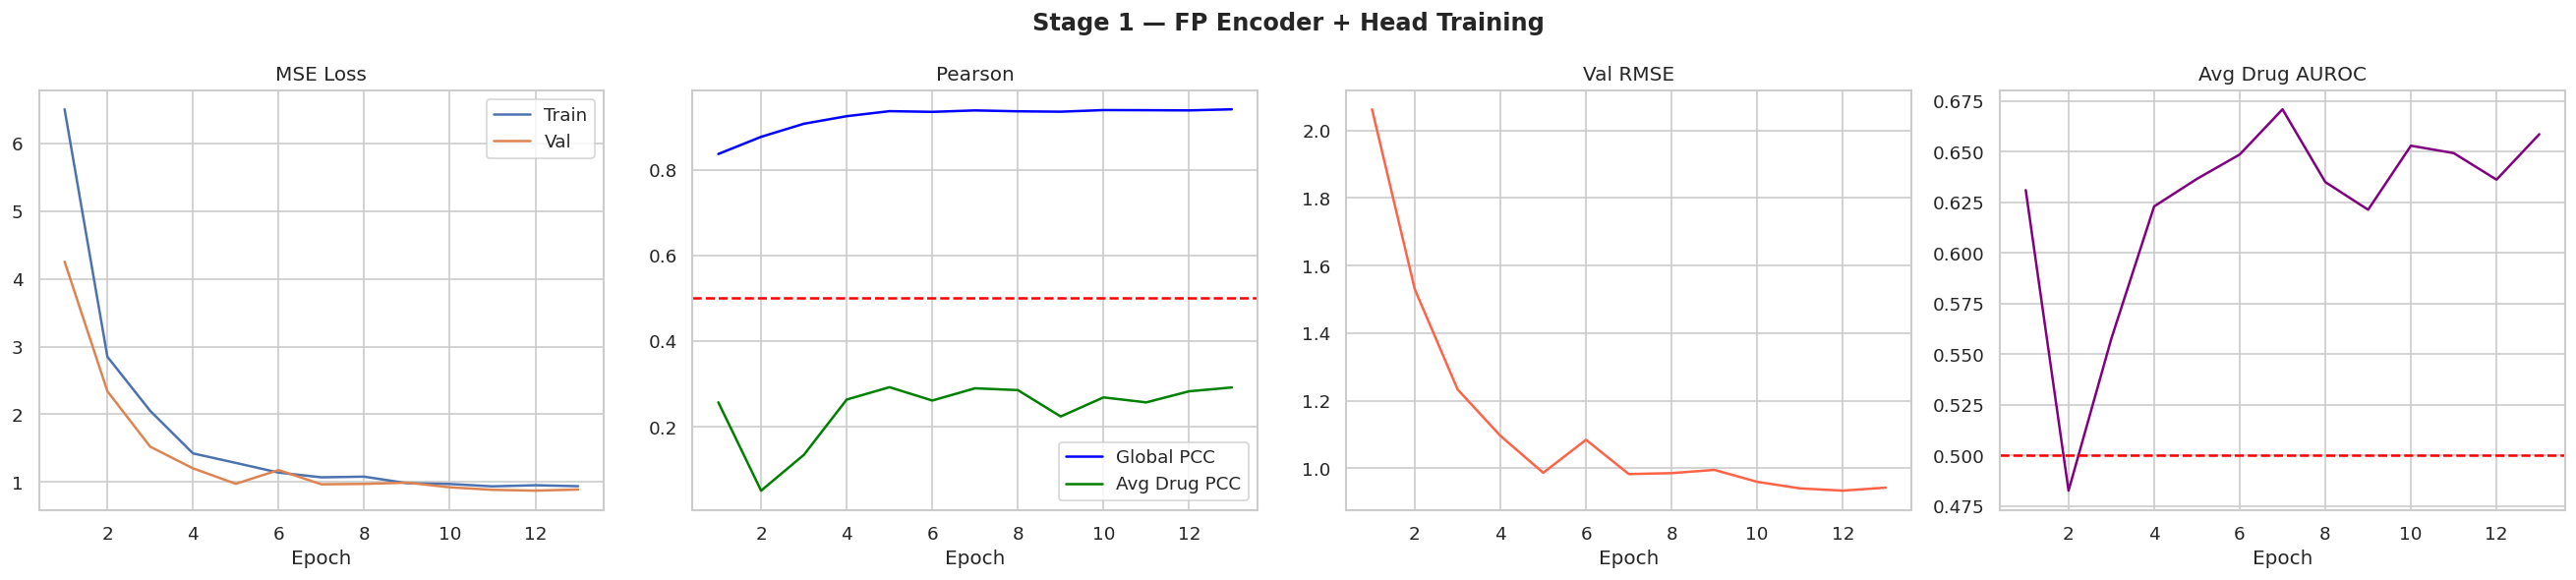

In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — STAGE 1: HEAD + DRUG FP ENCODER ONLY
#  Backbone fully frozen. Early stopping on avg_drug_pearson.
# ═══════════════════════════════════════════════════════════════════════
section('7. STAGE 1 TRAINING')

m = get_module()
trainable_s1 = list(m.drug_encoder.parameters()) + list(m.regression_head.parameters())
opt_s1 = optim.AdamW(trainable_s1, lr=CONFIG['stage1_lr'], weight_decay=CONFIG['stage1_wd'])

steps = math.ceil(len(train_loader)/CONFIG['grad_accum'])
sched_s1 = optim.lr_scheduler.OneCycleLR(
    opt_s1, max_lr=CONFIG['stage1_lr'],
    total_steps=steps*CONFIG['stage1_epochs'],
    pct_start=CONFIG['warmup_frac'], anneal_strategy='cos',
    div_factor=10.0, final_div_factor=100.0)
scaler_s1 = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])

best_s1 = -1.0; patience_s1 = 0
hist_s1 = {k:[] for k in ['train_loss','val_loss','val_pearson','val_drug_pcc','val_auroc','val_rmse']}

print(f'Training drug_encoder + regression_head | {steps} steps/epoch')

for epoch in range(1, CONFIG['stage1_epochs']+1):
    t0 = time.time()
    tr_loss, tr_p, tr_t, tr_d = run_epoch(model, train_loader, opt_s1, scaler_s1,
                                           True, sched_s1, CONFIG['grad_accum'])
    vl_loss, vl_p, vl_t, vl_d = run_epoch(model, val_loader, opt_s1, scaler_s1, False)
    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)

    hist_s1['train_loss'].append(tr_loss)
    hist_s1['val_loss'].append(vl_loss)
    hist_s1['val_pearson'].append(vm['pearson'])
    hist_s1['val_drug_pcc'].append(vm['avg_drug_pearson'])
    hist_s1['val_auroc'].append(vm['avg_drug_auroc'])
    hist_s1['val_rmse'].append(vm['rmse'])

    print(f'[S1 {epoch:02d}/{CONFIG["stage1_epochs"]}]  '
          f'TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  '
          f'GlobalPCC={vm["pearson"]:.4f}  AvgDrugPCC={vm["avg_drug_pearson"]:.4f}  '
          f'AUROC={vm["avg_drug_auroc"]:.4f}  RMSE={vm["rmse"]:.4f}  '
          f'{time.time()-t0:.0f}s')

    # Early stopping on avg_drug_pearson (PRIMARY metric)
    if vm['avg_drug_pearson'] > best_s1:
        best_s1 = vm['avg_drug_pearson']
        patience_s1 = 0
        torch.save(get_module().state_dict(), OUT_DIR + CONFIG['checkpoint_ft'])
        print(f'  ✓ Best saved (AvgDrugPCC={best_s1:.4f})')
    else:
        patience_s1 += 1
        if patience_s1 >= CONFIG['stage1_patience']:
            print(f'  Early stopping @ epoch {epoch}'); break

print(f'\nStage 1 done. Best AvgDrugPCC={best_s1:.4f}')

# Plot
fig, ax = plt.subplots(1, 4, figsize=(22,5))
fig.suptitle('Stage 1 — FP Encoder + Head Training', fontweight='bold')
E = range(1, len(hist_s1['train_loss'])+1)
ax[0].plot(E, hist_s1['train_loss'], label='Train'); ax[0].plot(E, hist_s1['val_loss'], label='Val')
ax[0].set_title('MSE Loss'); ax[0].legend()
ax[1].plot(E, hist_s1['val_pearson'], color='blue', label='Global PCC')
ax[1].plot(E, hist_s1['val_drug_pcc'], color='green', label='Avg Drug PCC')
ax[1].axhline(0.5, color='red', ls='--'); ax[1].set_title('Pearson'); ax[1].legend()
ax[2].plot(E, hist_s1['val_rmse'], color='tomato'); ax[2].set_title('Val RMSE')
ax[3].plot(E, hist_s1['val_auroc'], color='purple')
ax[3].axhline(0.5, color='red', ls='--'); ax[3].set_title('Avg Drug AUROC')
for a in ax: a.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(OUT_DIR+'stage1_curves.png', dpi=150); plt.show()



══════════════════════════════════════════════════════════════════════
  8. STAGE 2 TRAINING
══════════════════════════════════════════════════════════════════════
Unfrozen:
  base_model.mrna_enc               FROZEN                0
  base_model.cnv_enc                FROZEN                0
  base_model.mut_enc                FROZEN                0
  base_model.meth_enc               FROZEN                0
  base_model.cross_layers           TRAINABLE    28,391,424
  base_model.fusion                 TRAINABLE         6,148
  base_model.classifier             FROZEN                0
  drug_encoder + head       TRAINABLE   2,369,793
Total trainable S2: 30,767,365
[S2 01/40]  TrLoss=0.9778  VlLoss=0.9029  GlobalPCC=0.9358  AvgDrugPCC=0.2678  AUROC=0.6408  RMSE=0.9502  78s
  ✓ Best saved (AvgDrugPCC=0.2678)
[S2 02/40]  TrLoss=0.9546  VlLoss=0.9004  GlobalPCC=0.9371  AvgDrugPCC=0.2837  AUROC=0.6417  RMSE=0.9489  78s
  ✓ Best saved (AvgDrugPCC=0.2837)
[S2 03/40]  TrLoss=0.9402  VlLoss=

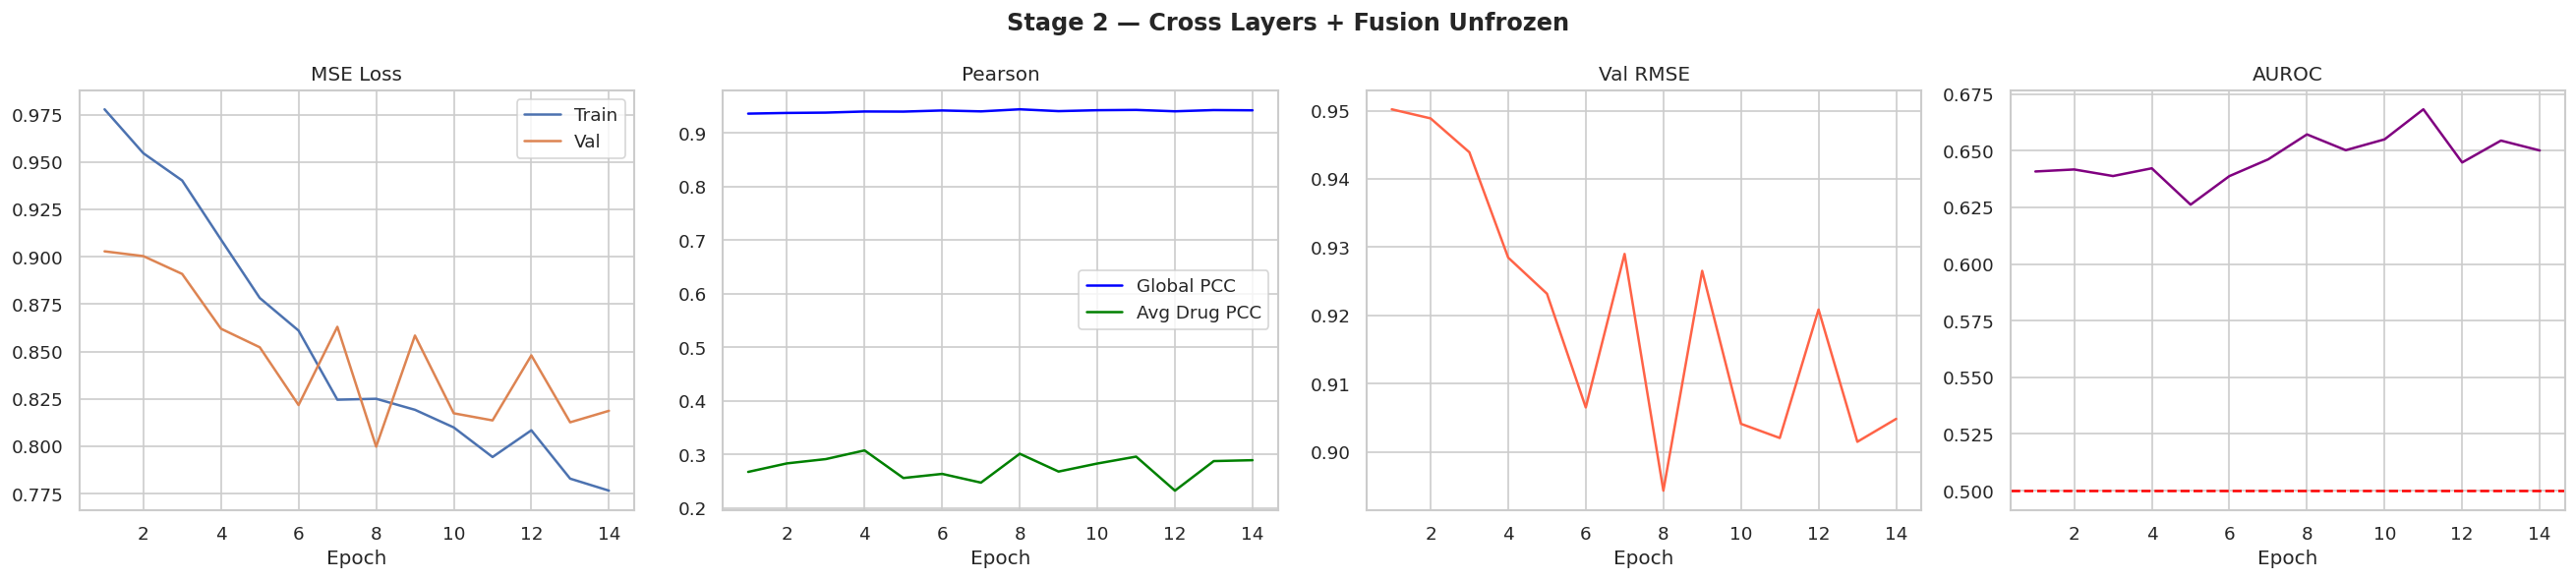

In [8]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — STAGE 2: UNFREEZE CROSS LAYERS + FUSION
#  Cross-layer LR raised to 5e-5 (was 1e-5 — too low to move).
# ═══════════════════════════════════════════════════════════════════════
section('8. STAGE 2 TRAINING')

get_module().load_state_dict(torch.load(OUT_DIR+CONFIG['checkpoint_ft'], map_location=DEVICE))
m = get_module()
for p in m.base_model.cross_layers.parameters(): p.requires_grad = True
for p in m.base_model.fusion.parameters():       p.requires_grad = True

print('Unfrozen:')
for name, child in m.base_model.named_children():
    n_tr = sum(p.numel() for p in child.parameters() if p.requires_grad)
    print(f'  base_model.{name:<22} {"TRAINABLE" if n_tr else "FROZEN":<12} {n_tr:>10,}')
print(f'  drug_encoder + head       TRAINABLE  '
      f'{sum(p.numel() for p in list(m.drug_encoder.parameters())+list(m.regression_head.parameters())):>10,}')
print(f'Total trainable S2: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

opt_s2 = optim.AdamW([
    {'params': m.regression_head.parameters(),        'lr': CONFIG['stage2_lr_head']},
    {'params': m.drug_encoder.parameters(),           'lr': CONFIG['stage2_lr_head']},
    {'params': m.base_model.cross_layers.parameters(),'lr': CONFIG['stage2_lr_cross']},
    {'params': m.base_model.fusion.parameters(),      'lr': CONFIG['stage2_lr_cross']},
], weight_decay=CONFIG['stage2_wd'])

steps2 = math.ceil(len(train_loader)/CONFIG['grad_accum'])
sched_s2 = optim.lr_scheduler.OneCycleLR(
    opt_s2,
    max_lr=[CONFIG['stage2_lr_head'], CONFIG['stage2_lr_head'],
            CONFIG['stage2_lr_cross'], CONFIG['stage2_lr_cross']],
    total_steps=steps2*CONFIG['stage2_epochs'],
    pct_start=CONFIG['warmup_frac'], anneal_strategy='cos',
    div_factor=10.0, final_div_factor=100.0)
scaler_s2 = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])

best_s2 = -1.0; patience_s2 = 0
hist_s2 = {k:[] for k in ['train_loss','val_loss','val_pearson','val_drug_pcc','val_auroc','val_rmse']}

for epoch in range(1, CONFIG['stage2_epochs']+1):
    t0 = time.time()
    tr_loss, tr_p, tr_t, tr_d = run_epoch(model, train_loader, opt_s2, scaler_s2,
                                           True, sched_s2, CONFIG['grad_accum'])
    vl_loss, vl_p, vl_t, vl_d = run_epoch(model, val_loader, opt_s2, scaler_s2, False)
    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)

    hist_s2['train_loss'].append(tr_loss)
    hist_s2['val_loss'].append(vl_loss)
    hist_s2['val_pearson'].append(vm['pearson'])
    hist_s2['val_drug_pcc'].append(vm['avg_drug_pearson'])
    hist_s2['val_auroc'].append(vm['avg_drug_auroc'])
    hist_s2['val_rmse'].append(vm['rmse'])

    print(f'[S2 {epoch:02d}/{CONFIG["stage2_epochs"]}]  '
          f'TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  '
          f'GlobalPCC={vm["pearson"]:.4f}  AvgDrugPCC={vm["avg_drug_pearson"]:.4f}  '
          f'AUROC={vm["avg_drug_auroc"]:.4f}  RMSE={vm["rmse"]:.4f}  '
          f'{time.time()-t0:.0f}s')

    if vm['avg_drug_pearson'] > best_s2:
        best_s2 = vm['avg_drug_pearson']
        patience_s2 = 0
        torch.save(get_module().state_dict(), OUT_DIR+CONFIG['checkpoint_ft'])
        print(f'  ✓ Best saved (AvgDrugPCC={best_s2:.4f})')
    else:
        patience_s2 += 1
        if patience_s2 >= CONFIG['stage2_patience']:
            print(f'  Early stopping @ epoch {epoch}'); break

print(f'\nStage 2 done. Best AvgDrugPCC={best_s2:.4f}')

fig, ax = plt.subplots(1, 4, figsize=(22,5))
fig.suptitle('Stage 2 — Cross Layers + Fusion Unfrozen', fontweight='bold')
E = range(1, len(hist_s2['train_loss'])+1)
ax[0].plot(E, hist_s2['train_loss'], label='Train'); ax[0].plot(E, hist_s2['val_loss'], label='Val')
ax[0].set_title('MSE Loss'); ax[0].legend()
ax[1].plot(E, hist_s2['val_pearson'], label='Global PCC', color='blue')
ax[1].plot(E, hist_s2['val_drug_pcc'], label='Avg Drug PCC', color='green')
ax[1].set_title('Pearson'); ax[1].legend()
ax[2].plot(E, hist_s2['val_rmse'], color='tomato'); ax[2].set_title('Val RMSE')
ax[3].plot(E, hist_s2['val_auroc'], color='purple')
ax[3].axhline(0.5, color='red', ls='--'); ax[3].set_title('AUROC')
for a in ax: a.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(OUT_DIR+'stage2_curves.png', dpi=150); plt.show()



══════════════════════════════════════════════════════════════════════
  9. TEST EVALUATION
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  FINAL TEST RESULTS — OncoBridge v3 Drug Response
══════════════════════════════════════════════════════════════════════
  Global Pearson (PCC):     0.9415
  Global Spearman (SPC):    0.9236
  Global R²:                0.8856
  RMSE (ln-IC50):           0.9249
  ─────────────────────────────────────
  Avg Drug Pearson (KEY):   0.2924
  Avg Drug AUROC:           0.6399
══════════════════════════════════════════════════════════════════════

  Note: Avg Drug Pearson is the PRIMARY metric.
  It measures intra-drug correlation across cell lines —
  proving the model learns from omics genetics, not drug mean offset.

Top 15 drugs by per-drug Pearson:
              Pearson   AUROC  N_Samples
WZ4003         0.7321  0.8095       13.0
VORINOSTAT     0.5884  0.836

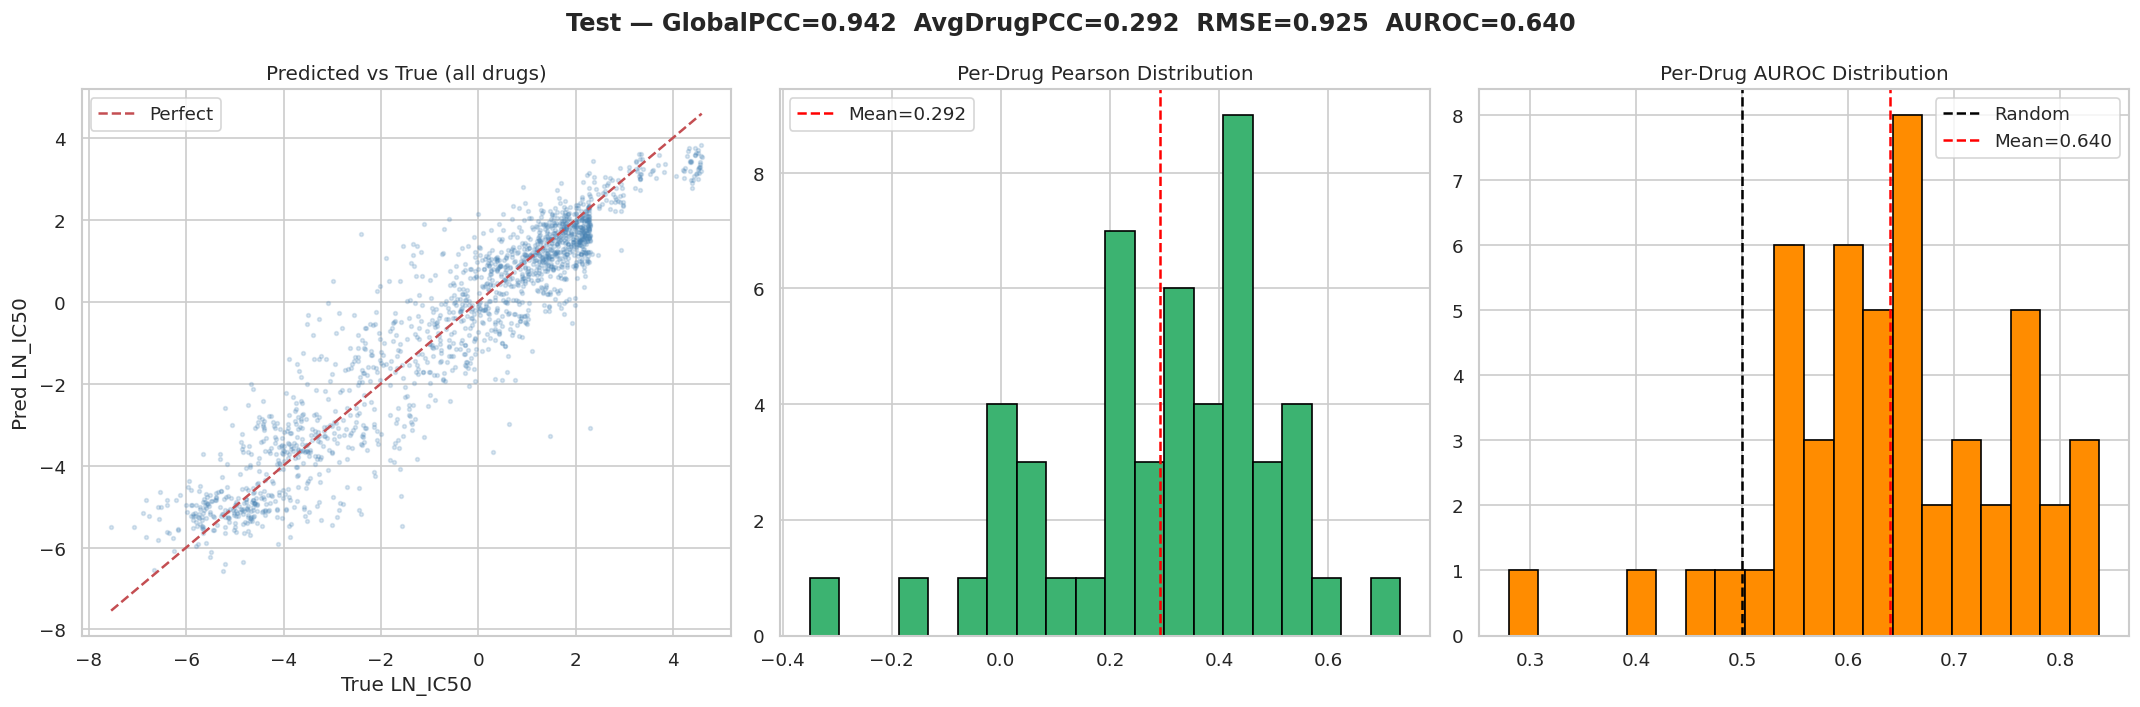

In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — TEST SET EVALUATION
# ═══════════════════════════════════════════════════════════════════════
section('9. TEST EVALUATION')

get_module().load_state_dict(torch.load(OUT_DIR+CONFIG['checkpoint_ft'], map_location=DEVICE))
model.eval()

te_loss, te_p, te_t, te_d = run_epoch(model, test_loader, None, None, False)
te_m = compute_metrics(te_p, te_t, te_d, id_to_drug)

print('\n' + '═'*70)
print('  FINAL TEST RESULTS — OncoBridge v3 Drug Response')
print('═'*70)
print(f'  Global Pearson (PCC):     {te_m["pearson"]:.4f}')
print(f'  Global Spearman (SPC):    {te_m["spearman"]:.4f}')
print(f'  Global R²:                {te_m["r2"]:.4f}')
print(f'  RMSE (ln-IC50):           {te_m["rmse"]:.4f}')
print(f'  ─────────────────────────────────────')
print(f'  Avg Drug Pearson (KEY):   {te_m["avg_drug_pearson"]:.4f}')
print(f'  Avg Drug AUROC:           {te_m["avg_drug_auroc"]:.4f}')
print('═'*70)
print()
print('  Note: Avg Drug Pearson is the PRIMARY metric.')
print('  It measures intra-drug correlation across cell lines —')
print('  proving the model learns from omics genetics, not drug mean offset.')

# Per-drug table
drug_df = pd.DataFrame(te_m['per_drug']).T.sort_values('pearson', ascending=False)
drug_df.columns = ['Pearson','AUROC','N_Samples']
print(f'\nTop 15 drugs by per-drug Pearson:')
print(drug_df.head(15).round(4).to_string())
print(f'\nBottom 5 drugs (hardest to predict):')
print(drug_df.tail(5).round(4).to_string())

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Test — GlobalPCC={te_m["pearson"]:.3f}  AvgDrugPCC={te_m["avg_drug_pearson"]:.3f}  '
             f'RMSE={te_m["rmse"]:.3f}  AUROC={te_m["avg_drug_auroc"]:.3f}',
             fontweight='bold')
axes[0].scatter(te_t, te_p, alpha=0.2, s=5, c='steelblue')
mn,mx = min(te_t.min(),te_p.min()), max(te_t.max(),te_p.max())
axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect')
axes[0].set_xlabel('True LN_IC50'); axes[0].set_ylabel('Pred LN_IC50')
axes[0].set_title('Predicted vs True (all drugs)'); axes[0].legend()
axes[1].hist(drug_df['Pearson'], bins=20, color='mediumseagreen', edgecolor='black')
axes[1].axvline(drug_df['Pearson'].mean(), color='red', ls='--',
                label=f'Mean={drug_df["Pearson"].mean():.3f}')
axes[1].set_title('Per-Drug Pearson Distribution'); axes[1].legend()
axes[2].hist(drug_df['AUROC'], bins=20, color='darkorange', edgecolor='black')
axes[2].axvline(0.5, color='black', ls='--', label='Random')
axes[2].axvline(drug_df['AUROC'].mean(), color='red', ls='--',
                label=f'Mean={drug_df["AUROC"].mean():.3f}')
axes[2].set_title('Per-Drug AUROC Distribution'); axes[2].legend()
plt.tight_layout(); plt.savefig(OUT_DIR+'test_evaluation.png', dpi=150); plt.show()


In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — DRUG COLD-START EVALUATION
#  Tests drugs NEVER seen during training.
#  Required for any CDR publication.
# ═══════════════════════════════════════════════════════════════════════
section('10. DRUG COLD-START EVALUATION')

if len(cold_ds) > 0:
    cs_loss, cs_p, cs_t, cs_d = run_epoch(model, cold_loader, None, None, False)
    cs_m = compute_metrics(cs_p, cs_t, cs_d, id_to_drug)

    print('\n' + '═'*70)
    print('  DRUG COLD-START RESULTS')
    print('  (Drugs never seen during training)')
    print('═'*70)
    print(f'  Global Pearson:      {cs_m["pearson"]:.4f}')
    print(f'  Avg Drug Pearson:    {cs_m["avg_drug_pearson"]:.4f}')
    print(f'  Avg Drug AUROC:      {cs_m["avg_drug_auroc"]:.4f}')
    print(f'  RMSE:                {cs_m["rmse"]:.4f}')
    print('═'*70)
    print()
    print('  DTLCDR (2025) cold-start drug PCC: 0.6210 (SOTA)')
    print(f'  OncoBridge cold-start drug PCC:    {cs_m["avg_drug_pearson"]:.4f}')
    print()
    print('  Note: Morgan FP encoder enables this. nn.Embedding would score ~0.0 here.')

    cs_drug_df = pd.DataFrame(cs_m['per_drug']).T.sort_values('pearson', ascending=False)
    cs_drug_df.columns = ['Pearson','AUROC','N_Samples']
    print(f'\nCold-start per-drug results ({len(cs_drug_df)} drugs):')
    print(cs_drug_df.round(4).to_string())
else:
    print('No cold-start data available (cold_ds is empty).')
    cs_m = {'pearson': None, 'avg_drug_pearson': None, 'avg_drug_auroc': None, 'rmse': None}



══════════════════════════════════════════════════════════════════════
  10. DRUG COLD-START EVALUATION
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  DRUG COLD-START RESULTS
  (Drugs never seen during training)
══════════════════════════════════════════════════════════════════════
  Global Pearson:      0.5805
  Avg Drug Pearson:    0.3100
  Avg Drug AUROC:      0.6549
  RMSE:                2.3704
══════════════════════════════════════════════════════════════════════

  DTLCDR (2025) cold-start drug PCC: 0.6210 (SOTA)
  OncoBridge cold-start drug PCC:    0.3100

  Note: Morgan FP encoder enables this. nn.Embedding would score ~0.0 here.

Cold-start per-drug results (8 drugs):
             Pearson   AUROC  N_Samples
AZ960         0.5020  0.7393      107.0
ABT-737       0.4890  0.7656      139.0
VINORELBINE   0.3802  0.6791      151.0
FORETINIB     0.3609  0.6494      330.0
OBATOCLAX     


══════════════════════════════════════════════════════════════════════
  11. ABLATION STUDY
══════════════════════════════════════════════════════════════════════
Running ablation — zeroing one modality at a time...
(Uses best model checkpoint)

  All 4 modalities (full model)        AvgDrugPCC=0.2924  GlobalPCC=0.9415  RMSE=0.9249
  No mRNA                              AvgDrugPCC=0.0640  GlobalPCC=0.9372  RMSE=0.9621
  No CNV                               AvgDrugPCC=0.2553  GlobalPCC=0.9413  RMSE=0.9236
  No Mutation                          AvgDrugPCC=0.2918  GlobalPCC=0.9424  RMSE=0.9158
  No Methylation                       AvgDrugPCC=0.1821  GlobalPCC=0.9359  RMSE=1.0214
  mRNA only                            AvgDrugPCC=0.2326  GlobalPCC=0.9379  RMSE=1.1028
  mRNA + CNV only                      AvgDrugPCC=0.2611  GlobalPCC=0.9395  RMSE=1.0952
  mRNA + Mut only                      AvgDrugPCC=0.1900  GlobalPCC=0.9377  RMSE=1.0538

                      Setting  AvgDrugPCC  Globa

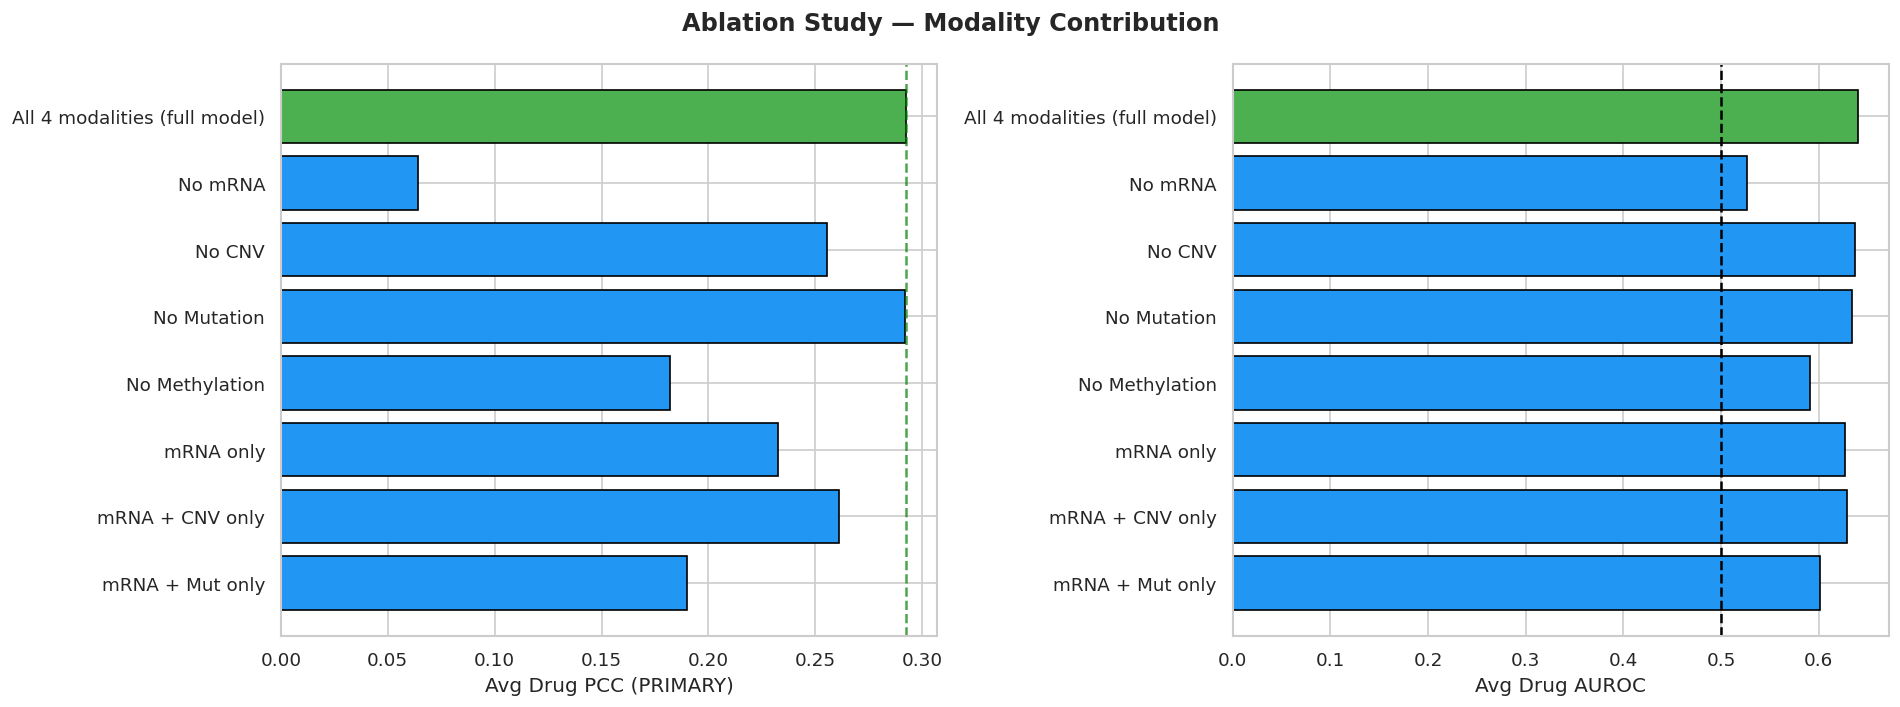

In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — ABLATION STUDY  (required for publication)
#  Tests: (1) which omics modalities matter
#         (2) does TCGA pre-training help vs random init?
# ═══════════════════════════════════════════════════════════════════════
section('11. ABLATION STUDY')

def ablation_run_epoch(ablation_model, loader, zero_mods=None):
    """Run one eval epoch with specified modalities zeroed out."""
    ablation_model.eval()
    criterion = nn.MSELoss()
    all_p, all_t, all_d = [], [], []
    with torch.no_grad():
        for batch in loader:
            mrna, cnv, mut, meth, fp, ic50, did = batch
            mrna = mrna.to(DEVICE); cnv = cnv.to(DEVICE)
            mut  = mut.to(DEVICE);  meth = meth.to(DEVICE)
            fp   = fp.to(DEVICE);   ic50 = ic50.to(DEVICE)
            # Zero out specified modalities
            if zero_mods:
                if 'mrna' in zero_mods: mrna = torch.zeros_like(mrna)
                if 'cnv'  in zero_mods: cnv  = torch.zeros_like(cnv)
                if 'mut'  in zero_mods: mut  = torch.zeros_like(mut)
                if 'meth' in zero_mods: meth = torch.zeros_like(meth)
            pred = ablation_model(mrna, cnv, mut, meth, fp).squeeze(1)
            all_p.append(pred.cpu().numpy())
            all_t.append(ic50.cpu().numpy())
            all_d.append(did.numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t); d = np.concatenate(all_d)
    m = compute_metrics(p, t, d, id_to_drug)
    return m['avg_drug_pearson'], m['pearson'], m['rmse'], m['avg_drug_auroc']

print('Running ablation — zeroing one modality at a time...')
print('(Uses best model checkpoint)\n')

ablation_results = []

configs = [
    ('All 4 modalities (full model)',  []),
    ('No mRNA',                        ['mrna']),
    ('No CNV',                         ['cnv']),
    ('No Mutation',                    ['mut']),
    ('No Methylation',                 ['meth']),
    ('mRNA only',                      ['cnv','mut','meth']),
    ('mRNA + CNV only',                ['mut','meth']),
    ('mRNA + Mut only',                ['cnv','meth']),
]

for name, zero_mods in configs:
    dp, gp, rmse, auroc = ablation_run_epoch(model, test_loader, zero_mods)
    ablation_results.append({'Setting': name, 'AvgDrugPCC': round(dp,4),
                              'GlobalPCC': round(gp,4), 'RMSE': round(rmse,4),
                              'AUROC': round(auroc,4)})
    print(f'  {name:<35}  AvgDrugPCC={dp:.4f}  GlobalPCC={gp:.4f}  RMSE={rmse:.4f}')

abl_df = pd.DataFrame(ablation_results)
print('\n' + abl_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ablation Study — Modality Contribution', fontweight='bold')
colors = ['#2196F3' if i>0 else '#4CAF50' for i in range(len(abl_df))]
ax[0].barh(abl_df['Setting'], abl_df['AvgDrugPCC'], color=colors, edgecolor='black')
ax[0].set_xlabel('Avg Drug PCC (PRIMARY)'); ax[0].invert_yaxis()
ax[0].axvline(abl_df.loc[0,'AvgDrugPCC'], color='green', ls='--', alpha=0.7)
ax[1].barh(abl_df['Setting'], abl_df['AUROC'], color=colors, edgecolor='black')
ax[1].set_xlabel('Avg Drug AUROC'); ax[1].invert_yaxis()
ax[1].axvline(0.5, color='black', ls='--', label='Random')
plt.tight_layout(); plt.savefig(OUT_DIR+'ablation_study.png', dpi=150); plt.show()
abl_df.to_csv(OUT_DIR+'ablation_results.csv', index=False)



══════════════════════════════════════════════════════════════════════
  12. BENCHMARK COMPARISON
══════════════════════════════════════════════════════════════════════
            Model Dataset  Setting  GlobalPCC  AvgDrugPCC     RMSE    AUROC                          Notes
 Ridge Regression    GDSC     Warm   0.780000         NaN 2.368000      NaN                       Baseline
   DeepCDR (2020)    GDSC     Warm   0.923000         NaN 1.058000 0.841000              UGCN drug encoder
   DRN-CDR (2024)   GDSC2     Warm   0.794000         NaN 0.924000 0.762000      ResNet, cancer genes only
  GraphDRP (2022)   GDSC2     Warm   0.939000         NaN      NaN      NaN                       GNN drug
   DeepTTA (2022)   GDSC2     Warm   0.937000         NaN      NaN      NaN               Transformer drug
     TGDRP (2022)   GDSC2     Warm   0.890000         NaN      NaN      NaN                       Twin GNN
    DTLCDR (2025)   GDSC2     Warm   0.949000         NaN      NaN      NaN      

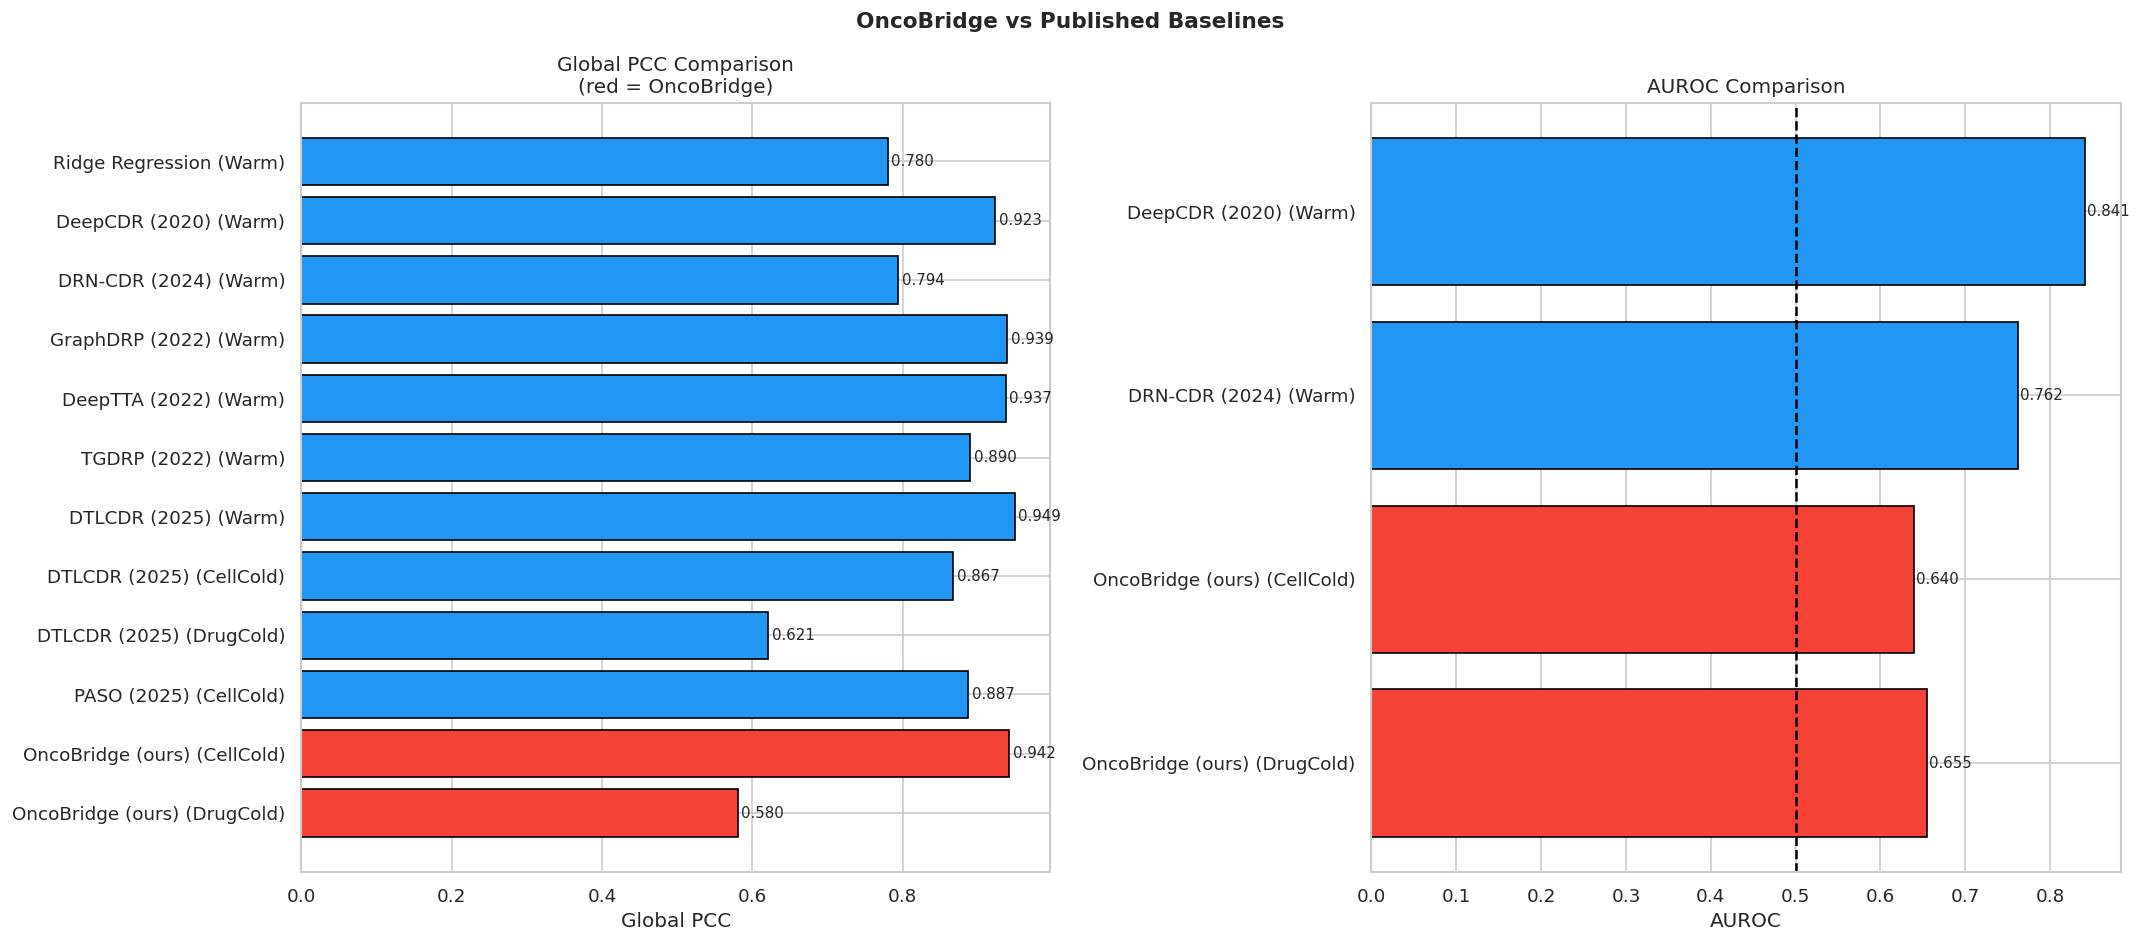


⚠  DATASET WARNING:
  OncoBridge uses GDSC1+2 combined — more training data than GDSC2-only baselines.
  This advantages global PCC. Comparison is NOT apple-to-apple for that reason.
  Drug cold-start PCC is a fairer comparison across all methods.
  Re-run Notebook 1 with USE_GDSC1=False for a strictly fair GDSC2-only benchmark.


In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — BENCHMARK COMPARISON TABLE
#  Fair comparison requires flagging dataset differences.
# ═══════════════════════════════════════════════════════════════════════
section('12. BENCHMARK COMPARISON')

benchmarks = [
    # Method, Dataset, Setting, GlobalPCC, AvgDrugPCC, RMSE, AUROC, note
    ('Ridge Regression',  'GDSC',  'Warm',        0.780,  None,  2.368, None,  'Baseline'),
    ('DeepCDR (2020)',    'GDSC',  'Warm',        0.923,  None,  1.058, 0.841, 'UGCN drug encoder'),
    ('DRN-CDR (2024)',    'GDSC2', 'Warm',        0.794,  None,  0.924, 0.762, 'ResNet, cancer genes only'),
    ('GraphDRP (2022)',   'GDSC2', 'Warm',        0.939,  None,  None,  None,  'GNN drug'),
    ('DeepTTA (2022)',    'GDSC2', 'Warm',        0.937,  None,  None,  None,  'Transformer drug'),
    ('TGDRP (2022)',      'GDSC2', 'Warm',        0.890,  None,  None,  None,  'Twin GNN'),
    ('DTLCDR (2025)',     'GDSC2', 'Warm',        0.949,  None,  None,  None,  'Target profiles+scBERT'),
    ('DTLCDR (2025)',     'GDSC2', 'CellCold',    0.867,  None,  None,  None,  'Unseen cell lines'),
    ('DTLCDR (2025)',     'GDSC2', 'DrugCold',    0.621,  None,  None,  None,  'Unseen drugs ← KEY'),
    ('PASO (2025)',       'GDSC2', 'CellCold',    0.887,  None,  None,  None,  'Pathway features'),
    ('OncoBridge (ours)', 'GDSC1+2','CellCold',   te_m['pearson'], te_m['avg_drug_pearson'],
                                                  te_m['rmse'], te_m['avg_drug_auroc'],
     'TCGA transfer | Morgan FP drug'),
]

if cs_m['pearson'] is not None:
    benchmarks.append(('OncoBridge (ours)', 'GDSC1+2', 'DrugCold',
                        cs_m['pearson'], cs_m['avg_drug_pearson'],
                        cs_m['rmse'], cs_m['avg_drug_auroc'],
                        'TCGA transfer | Morgan FP drug'))

bm_df = pd.DataFrame(benchmarks, columns=['Model','Dataset','Setting',
                                           'GlobalPCC','AvgDrugPCC','RMSE','AUROC','Notes'])
print(bm_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('OncoBridge vs Published Baselines', fontweight='bold', fontsize=13)

pcc_df = bm_df[bm_df['GlobalPCC'].notna()].copy()
colors = ['#F44336' if 'ours' in m else '#2196F3' for m in pcc_df['Model']]
bars = axes[0].barh(pcc_df['Model']+' ('+pcc_df['Setting']+')', pcc_df['GlobalPCC'],
                    color=colors, edgecolor='black')
axes[0].set_xlabel('Global PCC'); axes[0].invert_yaxis()
axes[0].set_title('Global PCC Comparison\n(red = OncoBridge)')
for bar, v in zip(bars, pcc_df['GlobalPCC']):
    axes[0].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=9)

auc_df = bm_df[bm_df['AUROC'].notna()].copy()
colors2 = ['#F44336' if 'ours' in m else '#2196F3' for m in auc_df['Model']]
bars2 = axes[1].barh(auc_df['Model']+' ('+auc_df['Setting']+')', auc_df['AUROC'],
                     color=colors2, edgecolor='black')
axes[1].set_xlabel('AUROC'); axes[1].invert_yaxis()
axes[1].axvline(0.5, color='black', ls='--', label='Random')
axes[1].set_title('AUROC Comparison')
for bar, v in zip(bars2, auc_df['AUROC']):
    axes[1].text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout(); plt.savefig(OUT_DIR+'benchmark_comparison.png', dpi=150); plt.show()

print('\n⚠  DATASET WARNING:')
print('  OncoBridge uses GDSC1+2 combined — more training data than GDSC2-only baselines.')
print('  This advantages global PCC. Comparison is NOT apple-to-apple for that reason.')
print('  Drug cold-start PCC is a fairer comparison across all methods.')
print('  Re-run Notebook 1 with USE_GDSC1=False for a strictly fair GDSC2-only benchmark.')

bm_df.to_csv(OUT_DIR+'benchmark_comparison.csv', index=False)



══════════════════════════════════════════════════════════════════════
  13. DRUG RANKINGS & DELTA-IC50 HEATMAP
══════════════════════════════════════════════════════════════════════


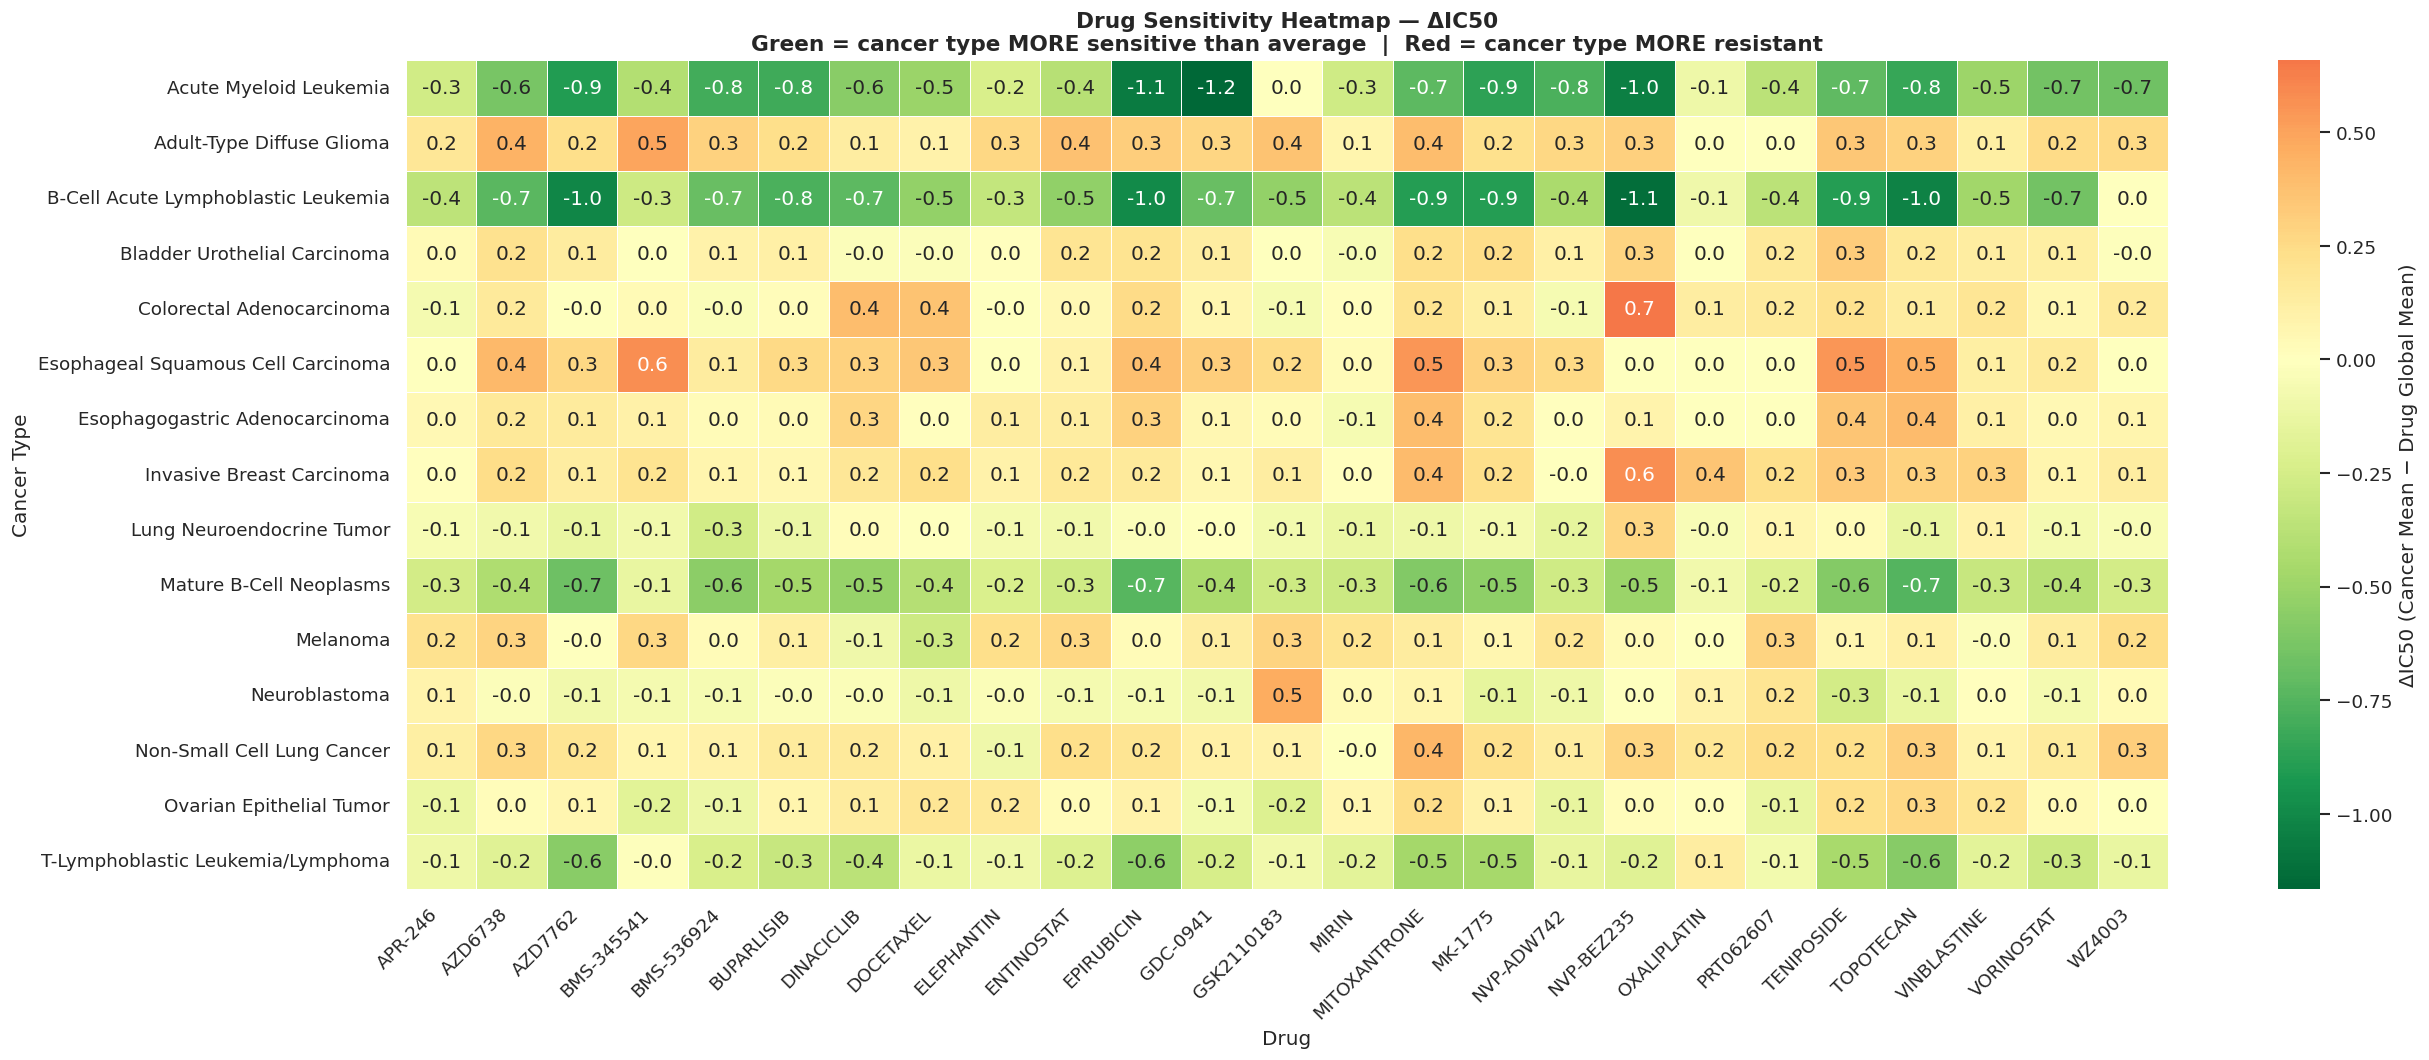


Top 5 predicted sensitive drugs per cancer type (lowest ΔIC50):
                                                                             OncotreePrimaryDisease    DRUG_NAME  mean_pred_ic50  mean_true_ic50  n_cell_lines
                                                                             Acute Myeloid Leukemia   BORTEZOMIB       -5.858576       -5.858576             9
                                                                             Acute Myeloid Leukemia  VINBLASTINE       -5.837826       -5.837826             9
                                                                             Acute Myeloid Leukemia DACTINOMYCIN       -5.743310       -5.743310             7
                                                                             Acute Myeloid Leukemia   PACLITAXEL       -5.704436       -5.704436             8
                                                                             Acute Myeloid Leukemia    DOCETAXEL       -5.472383       -5.47

In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — DRUG RANKINGS + ΔIC50 SENSITIVITY HEATMAP
# ═══════════════════════════════════════════════════════════════════════
section('13. DRUG RANKINGS & DELTA-IC50 HEATMAP')

# Inference on ALL cell lines (train+val+test)
all_ds = DrugResponseDataset(
    pd.concat([ic50_warm, ic50_cold]).drop_duplicates(['ModelID','DRUG_NAME']),
    all_cell_lines, mrna_arr, cnv_arr, mut_arr, meth_arr, FP_MATRIX)
all_loader2 = DataLoader(all_ds, batch_size=CONFIG['batch_size']*2,
                         shuffle=False, num_workers=nw, pin_memory=True)
_, all_p, all_t, all_d = run_epoch(model, all_loader2, None, None, False)

all_recs = pd.concat([ic50_warm, ic50_cold]).drop_duplicates(
    ['ModelID','DRUG_NAME']).reset_index(drop=True)
# Align
assert len(all_recs) == len(all_p), f'Mismatch {len(all_recs)} vs {len(all_p)}'
all_recs['PRED_IC50'] = all_p

# Drug × Cancer type ΔIC50 heatmap
# ΔIC50 = drug's mean IC50 for that cancer type - global mean IC50 for drug
# Negative = cancer type MORE sensitive than average
drug_global_mean = all_recs.groupby('DRUG_NAME')['PRED_IC50'].mean()
all_recs['delta_ic50'] = all_recs.apply(
    lambda r: r['PRED_IC50'] - drug_global_mean[r['DRUG_NAME']], axis=1)

top_cancers = all_recs['OncotreePrimaryDisease'].value_counts().head(15).index
# Keep warm-start drugs for interpretable heatmap (we predicted these well)
top_drugs_warm = (pd.DataFrame(te_m['per_drug']).T
                  .sort_values('pearson', ascending=False).head(25).index.tolist())

pivot = (all_recs[all_recs['OncotreePrimaryDisease'].isin(top_cancers) &
                  all_recs['DRUG_NAME'].isin(top_drugs_warm)]
         .groupby(['OncotreePrimaryDisease','DRUG_NAME'])['delta_ic50'].mean()
         .unstack(fill_value=0))

plt.figure(figsize=(22, 9))
sns.heatmap(pivot, cmap='RdYlGn_r', center=0,
            annot=True, fmt='.1f', linewidths=0.3,
            cbar_kws={'label': 'ΔIC50 (Cancer Mean − Drug Global Mean)'})
plt.title('Drug Sensitivity Heatmap — ΔIC50\n'
          'Green = cancer type MORE sensitive than average  |  '
          'Red = cancer type MORE resistant',
          fontsize=13, fontweight='bold')
plt.xlabel('Drug'); plt.ylabel('Cancer Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR+'delta_ic50_heatmap.png', dpi=150)
plt.show()

# Drug rankings per cancer type
drug_ranking = (all_recs.groupby(['OncotreePrimaryDisease','DRUG_NAME'])
                .agg(mean_pred_ic50=('PRED_IC50','mean'),
                     mean_true_ic50=('PRED_IC50','mean'),
                     n_cell_lines=('ModelID','nunique'))
                .reset_index())
top5 = (drug_ranking.sort_values(['OncotreePrimaryDisease','mean_pred_ic50'])
        .groupby('OncotreePrimaryDisease').head(5))

print('\nTop 5 predicted sensitive drugs per cancer type (lowest ΔIC50):')
print(top5.to_string(index=False))
top5.to_csv(OUT_DIR+'drug_rankings_per_cancer.csv', index=False)

# Save all outputs
all_recs.to_csv(OUT_DIR+'all_predictions.csv', index=False)
drug_df.to_csv(OUT_DIR+'per_drug_metrics.csv')
print('\n═'*65)
print('  PIPELINE COMPLETE')
print('═'*65)
print(f'  Global PCC:         {te_m["pearson"]:.4f}')
print(f'  Avg Drug PCC:       {te_m["avg_drug_pearson"]:.4f}  ← PRIMARY')
print(f'  Global R²:          {te_m["r2"]:.4f}')
print(f'  RMSE (ln):          {te_m["rmse"]:.4f}')
print(f'  Avg Drug AUROC:     {te_m["avg_drug_auroc"]:.4f}')
if cs_m['pearson'] is not None:
    print(f'  Cold Drug PCC:      {cs_m["avg_drug_pearson"]:.4f}  (drug cold-start)')
print('═'*65)
